# TP2: FINITE HORIZON MARKOV DECISION PROCESS 

**AUTHOR:** Lucía Porlán Ferrando

## LITTLEWOOD'S REVENUE MANAGEMENT MODEL

The problem is modeled as a Finite Horizon Markov Decision Process (MDP). In this environment, time is a critical variable as the 'inventory' (seats) expires at the end of the horizont $T=50$.
+ **State Space ($S$):** $s \in {0, 1, ..., 20}$, representing the number of availables seats.
+ **Action Space ($A$):** $a \in {1: \text{High Price}, 2: \text{Low Price}}$.
+ **Transition Probabilities:**
    + If a seat is sold (with probability $q_a$): $s \rightarrow s-1$.
    + If no seat is sold (with probability $1- q_a$): $s \rightarrow s$.
+ **Reward Function:** The expected immediate reward is $r(r,a) = q_a \cdot p_a$.

## BELLMAN EQUATION AND MARGINAL VALUE

The optimal value function $V_k(s)$ satisfies the Bellman optimality equation: $$V_k(s) = \max_{a \in \{1,2\}} \{ q_a p_a + q_a V_{k-1}(s-1) + (1-q_a) V_{k-1}(s) \}$$ The marginal value is defined as the value of having one additional seat available: $\Delta_{k-1}(s) = V_{k-1}(s) - V_{k-1}(s-1)$. By rearraging the optmality equation, it is shown that the High Price is preferred if: $$\Delta_{k-1}(s) \geq \frac{q_2 p_2 - q_1 p_1}{q_2 - q_1} = \frac{0.8(1) - 0.1(5)}{0.8 - 0.1} = \frac{0.3}{0.7} = \frac{3}{7} \approx 0.4286$$

In [1]:
import numpy as np

# Problem parameters
S = 20   
T = 50   

p1, q1 = 5, 0.1

p2, q2 = 1, 0.8

prices = [p1, p2]
probs = [q1, q2]
action_names = ["high price (5)", "plow price (1)"]

# V[k, s] = optimal value with k remaining days and s available seats.
V = np.zeros((T + 1, S + 1))

# policy[k, s] = optimal action in state (k, s) 
    # 0 -> high price, 1 -> low price
policy = -np.ones((T + 1, S + 1), dtype=int)


# Backward Dynamic Programmation 
for k in range(1, T + 1):
    for s in range(1, S + 1):
        values = []
        for a in range(2):
            p = prices[a]
            q = probs[a]

            val = q * p + q * V[k - 1, s - 1] + (1 - q) * V[k - 1, s]
            values.append(val)

        best_action = int(np.argmax(values))
        V[k, s] = values[best_action]
        policy[k, s] = best_action


print(f"Initial optimal value V[50,20] = {V[50,20]:.4f}")

print(f"Initial optimal action in (50 days, 20 seats): {action_names[policy[50,20]]}")

print("\nOptimal policy for k=50 remainig days:")
for s in range(1, S + 1):
    print(f"s={s:2d} -> {action_names[policy[50,s]]}")

Initial optimal value V[50,20] = 31.2806
Initial optimal action in (50 days, 20 seats): high price (5)

Optimal policy for k=50 remainig days:
s= 1 -> high price (5)
s= 2 -> high price (5)
s= 3 -> high price (5)
s= 4 -> high price (5)
s= 5 -> high price (5)
s= 6 -> high price (5)
s= 7 -> high price (5)
s= 8 -> high price (5)
s= 9 -> high price (5)
s=10 -> high price (5)
s=11 -> high price (5)
s=12 -> high price (5)
s=13 -> high price (5)
s=14 -> high price (5)
s=15 -> high price (5)
s=16 -> high price (5)
s=17 -> high price (5)
s=18 -> high price (5)
s=19 -> high price (5)
s=20 -> high price (5)


In [3]:
print("\nOptimal policy table:")
for k in range(1, T + 1):
    row = []
    for s in range(1, S + 1):
        row.append("H" if policy[k, s] == 0 else "L")
    print(f"k={k:2d}: {' '.join(row)}")


Optimal policy table:
k= 1: L L L L L L L L L L L L L L L L L L L L
k= 2: H L L L L L L L L L L L L L L L L L L L
k= 3: H L L L L L L L L L L L L L L L L L L L
k= 4: H H L L L L L L L L L L L L L L L L L L
k= 5: H H L L L L L L L L L L L L L L L L L L
k= 6: H H H L L L L L L L L L L L L L L L L L
k= 7: H H H L L L L L L L L L L L L L L L L L
k= 8: H H H H L L L L L L L L L L L L L L L L
k= 9: H H H H L L L L L L L L L L L L L L L L
k=10: H H H H H L L L L L L L L L L L L L L L
k=11: H H H H H L L L L L L L L L L L L L L L
k=12: H H H H H L L L L L L L L L L L L L L L
k=13: H H H H H H L L L L L L L L L L L L L L
k=14: H H H H H H L L L L L L L L L L L L L L
k=15: H H H H H H H L L L L L L L L L L L L L
k=16: H H H H H H H L L L L L L L L L L L L L
k=17: H H H H H H H H L L L L L L L L L L L L
k=18: H H H H H H H H L L L L L L L L L L L L
k=19: H H H H H H H H L L L L L L L L L L L L
k=20: H H H H H H H H H L L L L L L L L L L L
k=21: H H H H H H H H H L L L L L L L L L L L
k=22: H H H

In [2]:
threshold = 3 / 7

print("\nThreshold rule testing:")
for k in [1, 10, 20, 30, 40, 50]:
    print(f"\nRemaining days k={k}")
    for s in range(1, S + 1):
        delta = V[k - 1, s] - V[k - 1, s - 1]
        decision = "high price" if delta >= threshold else "low price"
        print(f"s={s:2d}, delta={delta:.4f}, decision={decision}")


Threshold rule testing:

Remaining days k=1
s= 1, delta=0.0000, decision=low price
s= 2, delta=0.0000, decision=low price
s= 3, delta=0.0000, decision=low price
s= 4, delta=0.0000, decision=low price
s= 5, delta=0.0000, decision=low price
s= 6, delta=0.0000, decision=low price
s= 7, delta=0.0000, decision=low price
s= 8, delta=0.0000, decision=low price
s= 9, delta=0.0000, decision=low price
s=10, delta=0.0000, decision=low price
s=11, delta=0.0000, decision=low price
s=12, delta=0.0000, decision=low price
s=13, delta=0.0000, decision=low price
s=14, delta=0.0000, decision=low price
s=15, delta=0.0000, decision=low price
s=16, delta=0.0000, decision=low price
s=17, delta=0.0000, decision=low price
s=18, delta=0.0000, decision=low price
s=19, delta=0.0000, decision=low price
s=20, delta=0.0000, decision=low price

Remaining days k=10
s= 1, delta=3.1920, decision=high price
s= 2, delta=1.4021, decision=high price
s= 3, delta=0.6343, decision=high price
s= 4, delta=0.4525, decision=high 

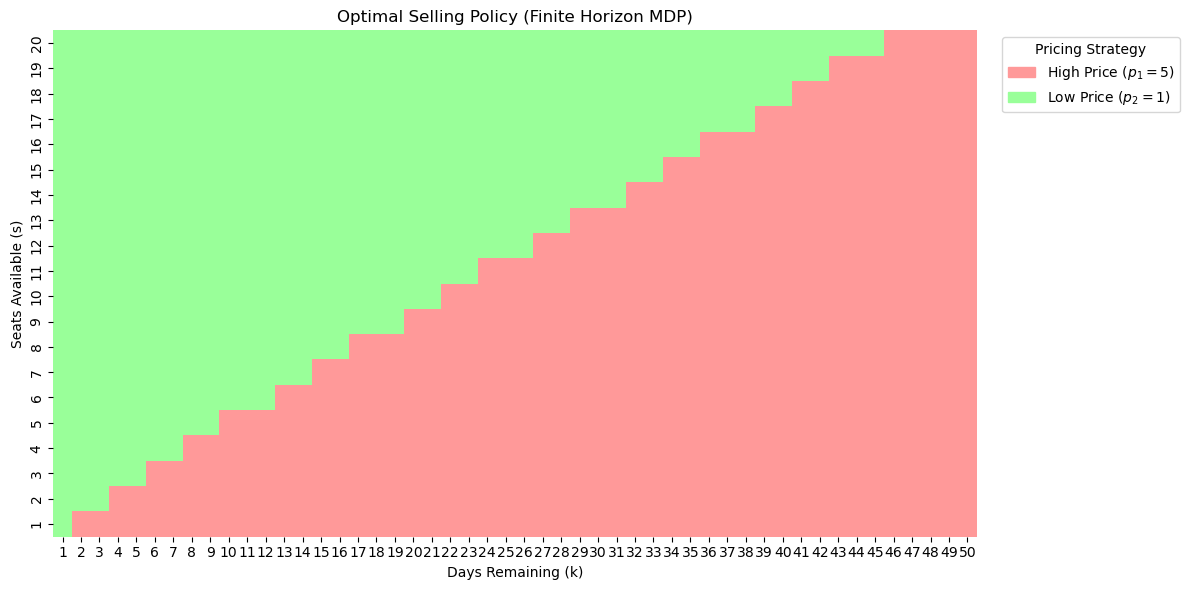

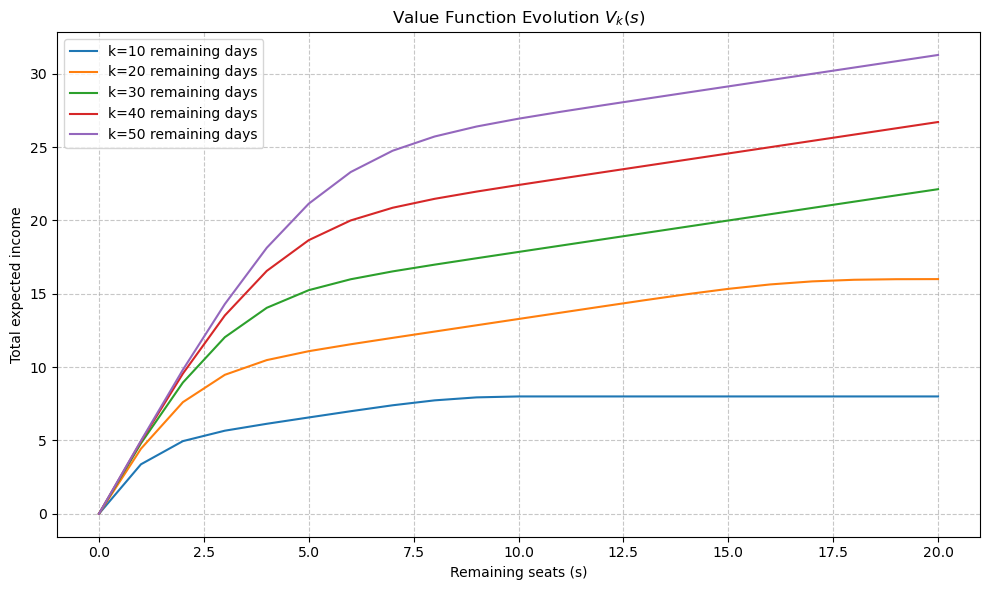

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns


# Figure 1: Otimal policy heat map
plt.figure(figsize=(12, 6))

policy_plot = policy[1:, 1:].T 

ax = sns.heatmap(policy_plot, cmap=["#ff9999", "#99ff99"], cbar=False, 
                 xticklabels=np.arange(1, T_max + 1), 
                 yticklabels=np.arange(1, S_max + 1))

high_patch = mpatches.Patch(color='#ff9999', label='High Price ($p_1=5$)')
low_patch = mpatches.Patch(color='#99ff99', label='Low Price ($p_2=1$)')

plt.legend(handles=[high_patch, low_patch], loc='upper left', 
           bbox_to_anchor=(1.02, 1), title="Pricing Strategy")

plt.title("Optimal Selling Policy (Finite Horizon MDP)")
plt.xlabel("Days Remaining (k)")
plt.ylabel("Seats Available (s)")
plt.gca().invert_yaxis() 
plt.tight_layout()

# Figure 2: Value function V_k(s)
plt.figure(figsize=(10, 6))
for k in [10, 20, 30, 40, 50]:
    plt.plot(np.arange(S_max + 1), V[k, :], label=f"k={k} remaining days")

plt.title("Value Function Evolution $V_k(s)$")
plt.xlabel("Remaining seats (s)")
plt.ylabel("Total expected income")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

## CONCLUSIONS

### Analysis of Numerical Results 

The backward dymanic programming solution provides the following insights:
+ **Initial State ($k = 50$, $s=20$):** The maximum expected revenue is 31.2806. This is significantly higher than the guaranteed revenue of selling all seats at the low price ($20 \times 1 = 20$), demonstrating that the MDP optimally leverages the remaining time to seek higher-paying customers.
+ **Time Horizon Effect:** With 50 days remainig, the optimal policy is to always charge the High Price for all seat levels. There is sufficient time to wait for low-probability, high-value sales.
    + With only 10 days remainig, the threshold drops to $s^*(10) \approx 5$. For $s=6$, the marginal value $\Delta \approx 0.4159$ is below the $0.4286$ threshold, triggering a switch to the Low Price to avoid expiring with empty seats.
+ **Scarcity and Marginal Utility:**
    + At $k = 20$, the marginal value for $s=9$ is $0.4286$, resulting in a High Price decision. However, for $s=10$, it drops to $0.4285$, switching the decision to Low Price. This confirms that as inventory increases, the marginal value of each seat decreases, incentivizing lower prices to stimulate demand.

### Qualitative Conclusion

The optimal policy follows a monotonic threshold structure:
1. For a fixed time $k$, there is a threshold $s^*(k)$ above which the price should be lowered to increase the probability of sale
2. For a fixed number of seats $s$, as time $k$ runs out, the marginal value of preserving capacity decreases, eventually leading to a price reduction.